In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import enchant
import re
from concurrent.futures import ThreadPoolExecutor
import gzip
import scipy.spatial.distance
import os
import scipy.stats as stats

In [2]:
import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\domin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
df = pd.read_csv("Game_data_05_08_24.csv")  

# Create the 'Success' column
df['Success'] = df.apply(lambda row: 1 if row['Guess'] == row['Mystery Word'] else 0, axis=1)

df.head()

,Table Number,Move,Clues,Mystery Word,Guess,Mode,Speed,Language,End,Success
0,312175859,1609,"Koperta, Naklejony, Pocztowy, Pocztówka",Stamp,Znaczek,NaN,NaN,NaN,NaN,0
1,312175859,1615,"W, Rimmikub, Glazura, Kwadracik",Tile,Płytka,NaN,NaN,NaN,NaN,0
2,312175859,1626,"Grajek, Baśń, Ta, Tuj",Rat,Bard,NaN,NaN,NaN,NaN,0
3,312175859,1632,"Płacony, Restauracja, Kid, Western",Bill,Tip,NaN,NaN,NaN,NaN,0
4,312175859,1638,"Władzy, Złoty, Tytanowy, Obrączka",Ring,Ring,NaN,NaN,NaN,NaN,1


Hier schreibe ich alles auf, was ich an dem Datensatz irgendwie verändere bzw. welche Probleme ich versuche zu lösen:

1. Das Sprachenproblem: ganz viele Runden haben leider keine Klassifizierung, in welcher Sprache sie gespielt wurden. Das ist insofern problematisch, da ich ja auch die Sprache als potenziellen Prädiktor nutzen möchte. Daher möchte ich für alle Runden die Sprache kennen. Wie finde ich also heraus, in welcher Sprache gespielt wurde?

**Lösungsansatz:**
Ich lasse Wörterbücher über Mystery Word, Guess und Clues laufen, um zunächst alle Sprachen zu erkennen. Dann vergleiche ich die erkannten Sprachen- wenn diese übereinstimmen, wird die Rundensprache auf das entsprechende Match festgelegt. Ein Beispiel: das Mystery Word ist 'Bathroom', der Guess 'Toilet' und die Clues sind 'Morning', 'Shower', 'Sink' und 'Towel'. Hierbei sollte der Algorithmus jetzt feststellen, dass alle Wörter in der englischen Sprache existieren und somit die Rundensprache auf Englisch setzen. 

**Probleme:** 
1. Die Wörterbücher erkennen viele Dinge nicht bzw. falsch. Gerade polnische Wörter sind für den Algorithmus schwierig. 
2. Die Wörter existieren in mehreren Sprachen. Z.B. das Wort 'Bad' existiert sowohl im Deutschen als auch im Englischen. Der Algorithmus erkennt hier insofern ein Match sowohl im deutschen als auch im englichen Wörterbuch. Das kann natürlich zu Problemen führen. Daher vergleicht der Algorithmus jeweils immer unabhängig- es ist nicht schlimm, wenn ein Wort in mehreren Sprachen existiert, solang eine der Sprachen über alle Kategorien matcht. 
3. 

2. Das Sprachenproblem, fortgesetzt: für spätere Analysen, besonders im Rahmen des Originalitätsmaßes, ist es wichtig, dass alle Wörter in der gleichen Sprache, also der Rundensprache sind. Denn logischerweise wäre ein Wort in französischer Sprache sehr weit entfernt von einem in der deutschen Sprache- selbst wenn die Bedeutung gar nicht so weit voneinander entfernt ist. Daher müssen tatsächlich alle Wörter, die nicht in der Rundensprache existieren, aussortiert werden- und ihre Runden der Konsistenz halber gleich mit. Um das zu erreichen, werde ich eine zweite Runde an Checks einbauen, die, sobald eine Sprache festgelegt wurde, die Clues erneut überprüft, und im Fall, dass ein Wort nicht im Wörterbuch dieser Sprache existiert, die Runde entfernt. 

Hierbei muss ich aber noch schauen, wieviele Datenpunkte mir hinterher übrig bleiben. 

## Documentation for Removing Rounds with NaN Values and Storing Them Separately

### Overview
This script is designed to clean a dataset by identifying and removing rounds (rows) that contain missing values (`NaN`) in key columns. The removed rounds are stored in a separate dataset for potential future analysis or review. The script also provides a summary of how many rounds were retained and how many were removed.

### Purpose
The cleaning process focuses on four key columns:
1. `Mode`
2. `Speed`
3. `Language`
4. `End`

Rounds with missing values in any of these columns are considered incomplete and are removed from the main dataset. The removed rounds are stored in a separate dataset, allowing for a clear distinction between complete and incomplete data.

### Code Breakdown

1. **Loading the Dataset**:
   - The dataset is loaded into a pandas DataFrame for processing.

2. **Identifying and Separating Incomplete Rounds**:
   - The script checks for missing (`NaN`) values in the specified columns (`Mode`, `Speed`, `Language`, `End`).
   - Rounds with any `NaN` values in these columns are separated into a new DataFrame (`removed_rounds`).
   - The remaining rounds, which are complete, are stored in another DataFrame (`cleaned_data`).

3. **Counting the Rounds**:
   - The script calculates and prints the number of rounds that were retained (i.e., those without `NaN` values).
   - It also calculates and prints the number of rounds that were removed due to missing values.

4. **Output**:
   - The cleaned dataset is ready for further analysis, while the removed rounds are preserved for any necessary follow-up.


In [5]:
# Separate the rounds with NaN values in 'Mode', 'Speed', 'Language', or 'End' columns
cleaned_data = df.dropna(subset=['Mode', 'Speed', 'Language', 'End'])

# Count the number of rounds
total_rounds = df.shape[0]
cleaned_rounds_count = cleaned_data.shape[0]


# Print the counts
cleaned_rounds_count

14035

# Documentation: Removing Rounds Based on Clue Content

## Overview
This script is designed to clean a dataset by identifying and removing entire rounds (rows) of data where any clue contains special characters, numbers, or multiple words (indicated by spaces). The script also saves the removed rounds to a separate CSV file for further analysis or review.

## Purpose
The goal of this script is to ensure the integrity of your dataset by removing any rounds that could skew the analysis. Specifically, it addresses the following issues:
1. **Special Characters**: Any clue containing characters other than letters, numbers, underscores, or spaces is flagged.
2. **Numbers**: Clues containing numeric digits are flagged.
3. **Multiple Words**: Clues containing more than one word (indicated by spaces) are flagged.

If any clue in a round meets any of these criteria, the entire round is removed from the dataset.

## Code Breakdown

### 1. **Copying the Dataset**
   - `df_cleaned = cleaned_data.copy()`
   - This creates a copy of the original dataset to avoid modifying it directly. All cleaning operations are performed on this copy.

### 2. **Initialization**
   - The script initializes dictionaries to store the counts and lists of removed words based on the specific reason for their removal:
     - `special_characters`
     - `numbers`
     - `spaces`

### 3. **Defining the `clean_rounds` Function**
   - This function iterates over each row in the dataset and checks each clue in the 'Clues' column:
     - **Special Characters**: Uses the regular expression `r'[^\w\s]'` to identify and flag any special characters.
     - **Numbers**: Uses `r'\d'` to detect any numeric digits in the clues.
     - **Spaces**: Checks for spaces to determine if the clue consists of multiple words.
   - If any clue in a round meets the criteria, the round is marked for deletion.
   - The removed rounds are saved to a separate DataFrame.

### 4. **Applying the `clean_rounds` Function**
   - `df_cleaned, removed_rounds = clean_rounds(df_cleaned, 'Clues')`
   - The function is applied to the dataset, cleaning it by removing the identified rounds and storing those rounds separately.

### 5. **Saving the Results**
   - The cleaned dataset and the removed rounds are saved to separate CSV files:
     - `'cleaned_data_with_cleaned_clues.csv'` for the cleaned data.
     - `'removed_rounds.csv'` for the rounds that were removed.

### 6. **Summary Output**
   - The script prints a summary of the number of words (or clues) that were flagged and removed for each category (`special_characters`, `numbers`, `spaces`).

In [6]:
# Create a copy of the dataset to avoid modifying the original data
df_cleaned = cleaned_data.copy()

# Initialize dictionaries to store removed words counts and lists
removed_words_counts = {
    'special_characters': 0,
    'numbers': 0,
    'spaces': 0
}

removed_words_lists = {
    'special_characters': [],
    'numbers': [],
    'spaces': []
}

# Function to clean entire rounds if any clue contains undesired characters
def clean_rounds(dataframe, column_name):
    rows_to_drop = []
    for index, clues_string in dataframe[column_name].items():
        clues_list = str(clues_string).split(',')
        for clue in clues_list:
            original_clue = clue.strip()
            
            # Check for special characters
            if re.search(r'[^\w\s]', original_clue):
                removed_words_lists['special_characters'].append(original_clue)
                removed_words_counts['special_characters'] += 1
                rows_to_drop.append(index)
                break  # Skip further checks and mark the round for deletion
            
            # Check for numbers
            if re.search(r'\d', original_clue):
                removed_words_lists['numbers'].append(original_clue)
                removed_words_counts['numbers'] += 1
                rows_to_drop.append(index)
                break  # Skip further checks and mark the round for deletion
            
            # Check for spaces (multiple words)
            if ' ' in original_clue:
                removed_words_lists['spaces'].append(original_clue)
                removed_words_counts['spaces'] += 1
                rows_to_drop.append(index)
                break  # Skip further checks and mark the round for deletion

    # Save the removed rounds to a separate DataFrame
    removed_rounds = dataframe.loc[rows_to_drop]
    
    # Drop the identified rows from the original DataFrame
    dataframe = dataframe.drop(rows_to_drop)

    return dataframe, removed_rounds

# Apply the function to delete rounds instead of just words
df_cleaned, removed_rounds = clean_rounds(df_cleaned, 'Clues')

# Save the cleaned DataFrame and removed rounds DataFrame to CSV files
df_cleaned.to_csv('cleaned_data_with_cleaned_clues.csv', index=False)
removed_rounds.to_csv('removed_rounds.csv', index=False)

# Print out the counts of removed words for each category
print("Summary of Removed Words:")
print(f" - Special Characters: {removed_words_counts['special_characters']}")
print(f" - Numbers: {removed_words_counts['numbers']}")
print(f" - Spaces (multiple words): {removed_words_counts['spaces']}")
print(f" - Total Removed Words: {sum(removed_words_counts.values())}")

print("\nFiles have been saved:")
print(" - Cleaned data with cleaned clues: 'cleaned_data_with_cleaned_clues.csv'")
print(" - Removed rounds: 'removed_rounds.csv'")



Summary of Removed Words:
 - Special Characters: 1100
 - Numbers: 319
 - Spaces (multiple words): 0
 - Total Removed Words: 1419

Files have been saved:
 - Cleaned data with cleaned clues: 'cleaned_data_with_cleaned_clues.csv'
 - Removed rounds: 'removed_rounds.csv'


# Documentation: Dictionary Validation and Clue Processing

## Overview
This script processes a dataset containing clues in multiple languages, validating each clue against language-specific dictionaries. It categorizes rounds based on the percentage of clues that are valid according to the dictionary and saves the results in different CSV files. The script also counts and prints the number of rows for each language, specifically focusing on French in this case.

## Purpose
The goal of this script is to clean and validate a dataset of clues by ensuring that they exist in the appropriate language dictionary. The script categorizes the rounds based on the percentage of valid clues and generates corresponding CSV files for further analysis.

## Code Breakdown

### 1. **Loading Dictionaries**
   - The function `load_dictionary(file_name)` loads a dictionary file and converts the list of words into a lowercase set for efficient lookup.
   - Dictionaries for English (`words.txt`), German (`vocab_german.txt`), and French (`francais.txt`) are loaded. The French dictionary came from this Git: https://github.com/Taknok/French-Wordlist/blob/master/francais.txt

### 2. **Loading the Cleaned Dataset**
   - The dataset is loaded from a CSV file named `cleaned_data_with_cleaned_clues.csv` into the DataFrame `df_cleaned_with_cleaned_clues`.

### 3. **Validating Clues Against Dictionaries**
   - The function `check_clues_against_dictionary(dataframe, clues_column, language_column)` iterates through each round in the dataset and validates clues against the appropriate dictionary based on the language of the round.
   - **Categorization**:
     - **Fully Valid Rounds**: Rounds where all clues are valid.
     - **At Least 75% Valid Rounds**: Rounds where at least 75% of the clues are valid.
     - **At Least 50% Valid Rounds**: Rounds where at least 50% of the clues are valid.
     - **Invalid Rounds**: Rounds where fewer than 50% of the clues are valid.
   - The function returns four DataFrames corresponding to these categories.

### 5. **Saving the Results**
   - The categorized DataFrames are saved as separate CSV files:
     - `fully_valid_clues.csv`: Contains only rounds where every clue is valid.
     - `atleast_75_valid_clues.csv`: Contains rounds where at least 75% of clues are valid.
     - `atleast_50_valid_clues.csv`: Contains rounds where at least 50% of clues are valid.
     - `invalid_rounds_due_to_dictionary.csv`: Contains rounds where fewer than 50% of the clues are valid.

### 6. **Printing the Summary**
   - The script prints a summary of the number of rounds in each category:
     - **Rounds where every clue is valid**: Count of fully valid rounds.
     - **Rounds where at least 75% of clues are valid**: Count of rounds with at least 75% valid clues.
     - **Rounds where at least 50% of clues are valid**: Count of rounds with at least 50% valid clues.
     - **Rounds rejected due to invalid clues**: Count of rounds with fewer than 50% valid clues.
   - The total number of rows in the dataset is also printed.

### 7. **Output Files**
   - **`fully_valid_clues.csv`**: Rounds where all clues are valid.
   - **`atleast_75_valid_clues.csv`**: Rounds with at least 75% valid clues.
   - **`atleast_50_valid_clues.csv`**: Rounds with at least 50% valid clues.
   - **`invalid_rounds_due_to_dictionary.csv`**: Rounds with less than 50% valid clues.

In [5]:
# Load dictionaries for each language
def load_dictionary(file_name):
    with open(file_name, 'r') as file:
        return set(word.strip().lower() for word in file.readlines())

# Load the dictionaries (adjust the file paths as necessary)
english_words = load_dictionary('words.txt')
german_words = load_dictionary('vocab_german.txt')
french_words = load_dictionary('francais.txt')

# Function to check if clues exist in the respective language's dictionary
def check_clues_against_dictionary(dataframe, clues_column, language_column):
    all_valid_rows = []
    atleast_75_valid_rows = []
    atleast_50_valid_rows = []
    invalid_rows = []

    for index, row in dataframe.iterrows():
        clues_list = str(row[clues_column]).split(',')
        language = row[language_column].strip().lower()

        # Select the correct dictionary based on the language of the round
        if language == 'english':
            dictionary = english_words
        elif language == 'deutsch':
            dictionary = german_words
        elif language == 'français':
            dictionary = french_words 
        else:
            continue  # Skip if the language is not recognized
        
        valid_clues = [clue.strip().lower() for clue in clues_list if clue.strip().lower() in dictionary]
        total_clues = len(clues_list)
        valid_clues_count = len(valid_clues)

        # Categorize the row based on the percentage of valid clues
        if valid_clues_count == total_clues:
            all_valid_rows.append(index)
            atleast_75_valid_rows.append(index)
            atleast_50_valid_rows.append(index)
        elif valid_clues_count >= 0.75 * total_clues:
            atleast_75_valid_rows.append(index)
            atleast_50_valid_rows.append(index)
        elif valid_clues_count >= 0.50 * total_clues:
            atleast_50_valid_rows.append(index)
        else:
            invalid_rows.append(index)

    # Create DataFrames based on the indices
    df_all_valid = dataframe.loc[all_valid_rows]
    df_atleast_75_valid = dataframe.loc[atleast_75_valid_rows]
    df_atleast_50_valid = dataframe.loc[atleast_50_valid_rows]
    df_invalid = dataframe.loc[invalid_rows]

    return df_all_valid, df_atleast_75_valid, df_atleast_50_valid, df_invalid

df_cleaned_with_cleaned_clues = pd.read_csv("cleaned_data_with_cleaned_clues.csv")

df_all_valid, df_atleast_75_valid, df_atleast_50_valid, df_invalid = check_clues_against_dictionary(df_cleaned_with_cleaned_clues, 'Clues', 'Language')

# Save the DataFrames to CSV files
df_all_valid.to_csv('fully_valid_clues.csv', index=False)
df_atleast_75_valid.to_csv('atleast_75_valid_clues.csv', index=False)
df_atleast_50_valid.to_csv('atleast_50_valid_clues.csv', index=False)
df_invalid.to_csv('invalid_rounds_due_to_dictionary.csv', index=False)



# Print out the counts of rounds in each category
print("Summary of Rounds Based on Dictionary Validation:")
print(f" - Rounds where every clue is valid: {len(df_all_valid)}")
print(f" - Rounds where at least 75% of clues are valid: {len(df_atleast_75_valid)}")
print(f" - Rounds where at least 50% of clues are valid: {len(df_atleast_50_valid)}")
print(f" - Rounds rejected due to invalid clues: {len(df_invalid)}")
print(f"Total number of rows in the dataset: {len(df_cleaned_with_cleaned_clues)}")

print("\nFiles have been saved:")
print(" - Fully valid clues: 'fully_valid_clues.csv'")
print(" - At least 75% valid clues: 'atleast_75_valid_clues.csv'")
print(" - At least 50% valid clues: 'atleast_50_valid_clues.csv'")
print(" - Invalid rounds: 'invalid_rounds_due_to_dictionary.csv'")

Summary of Rounds Based on Dictionary Validation:
 - Rounds where every clue is valid: 4965
 - Rounds where at least 75% of clues are valid: 8246
 - Rounds where at least 50% of clues are valid: 11050
 - Rounds rejected due to invalid clues: 1566
Total number of rows in the dataset: 12616

Files have been saved:
 - Fully valid clues: 'fully_valid_clues.csv'
 - At least 75% valid clues: 'atleast_75_valid_clues.csv'
 - At least 50% valid clues: 'atleast_50_valid_clues.csv'
 - Invalid rounds: 'invalid_rounds_due_to_dictionary.csv'


In [9]:
valid = pd.read_csv('fully_valid_clues.csv')# Count how many entries are 'English', 'German', 'French' in the 'Language' column
language_counts = valid['Language'].value_counts()

# Print the counts for each language
print(language_counts)

Language
English     4090
Deutsch      584
Français     291
Name: count, dtype: int64


At this point, the data cleaning is done. We have removed all the characters that do not belong and checked for the clues existing in dictionaries. To be able to check robustness later on, we have created datasets with different levels of validity. 

The next thing will be to run analyses on the data. To do this, we will begin with 

In [3]:
# Get all .csv files in the current folder
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]

# Load the notebook file (assuming it's a Jupyter Notebook, replace with your notebook filename)
notebook_file = 'Code.ipynb'

# Read the contents of the notebook
with open(notebook_file, 'r', encoding='utf-8') as f:
    notebook_content = f.read()

# Check which CSV files are used in the notebook
used_files = []
unused_files = []

for csv_file in csv_files:
    if csv_file in notebook_content:
        used_files.append(csv_file)
    else:
        unused_files.append(csv_file)

# Output the results
print("Used CSV files:")
for file in used_files:
    print(f"- {file}")

print("\nUnused CSV files (can be deleted):")
for file in unused_files:
    print(f"- {file}")

Used CSV files:
- 100_valid_with_dummies.csv
- atleast_50_valid_clues.csv
- atleast_75_valid_clues.csv
- cleaned_data_with_cleaned_clues.csv
- fully_valid_clues.csv
- Game_data_05_08_24.csv
- invalid_rounds_due_to_dictionary.csv
- removed_rounds.csv
- transformed_data.csv
- transformed_speed_data.csv

Unused CSV files (can be deleted):
- clues_only.csv
- DAT_Data.csv
- DAT_Data_Score.csv
- english_originality.csv
- Game_data_25_04_24.csv
- Game_data_cleaned.csv
- Game_data_clues.csv
- Game_data_mystery_words.csv
- Game_data_unique_clues.csv
- Game_data_with_language_match.csv
- german_originality.csv
- Removed_Words.csv
- removed_words_summary.csv


In [6]:
df_100_valid = pd.read_csv("fully_valid_clues.csv")
df_75_valid = pd.read_csv("atleast_75_valid_clues.csv")
df_50_valid = pd.read_csv("atleast_50_valid_clues.csv")

dataset_english = pd.read_csv('english_originality.csv')

In [9]:
# Assuming df_100_valid is your original DataFrame
copy_100_valid = df_100_valid.copy()

# Define a mapping for the 'Speed' variable based on the type and speed
speed_mapping = {
    'Fast Turn-based • 12 moves per day': (7, 'Turn-based'),
    'Fast Turn-based • 24 moves per day': (8, 'Turn-based'),
    'Fast Turn-based • 8 moves per day': (6, 'Turn-based'),
    'No time limit • with friends only': (1, 'No time limit'),
    'Real-time • Fast paced': (2, 'Real-time'),
    'Real-time • Normal speed': (1, 'Real-time'),
    'Turn-based • 1 move per 2 days': (1, 'Turn-based'),
    'Turn-based • 1 move per day': (2, 'Turn-based'),
    'Turn-based • 2 moves per day': (3, 'Turn-based'),
    'Turn-based • 3 moves per day': (4, 'Turn-based'),
    'Turn-based • 4 moves per day': (5, 'Turn-based')
}

# Apply the mapping to create new columns for each speed type
for speed, (code, category) in speed_mapping.items():
    # Create a new column for each category if it doesn't already exist
    if category not in copy_100_valid.columns:
        copy_100_valid[category] = None
    
    # Assign the mapped value to the respective category column
    copy_100_valid.loc[copy_100_valid['Speed'] == speed, category] = code

# Drop the original 'Speed' column since we have split it into multiple categories
copy_100_valid.drop('Speed', axis=1, inplace=True)

# Now, let's print out the new columns and their mappings
for category in ['No time limit', 'Real-time', 'Turn-based']:
    if category in copy_100_valid.columns:
        print(f"\nMapping for {category}:")
        print(copy_100_valid[category].unique())

# Show the first few rows of the transformed DataFrame
print("\nTransformed DataFrame:")
print(copy_100_valid.head())

# Save the transformed DataFrame to a new CSV file
copy_100_valid.to_csv('transformed_speed_data.csv', index=False)

print("\nTransformed DataFrame saved as 'transformed_speed_data.csv'.")

# Step 1: Create dummy variables for the speed types, handling NaN values
df_filtered['Is_Turn_based'] = df_filtered['Turn-based'].apply(lambda x: 1 if pd.notna(x) and x > 0 else 0)
df_filtered['Is_Real_time'] = df_filtered['Real-time'].apply(lambda x: 1 if pd.notna(x) and x > 0 else 0)

# Step 2: Create the interaction terms for Turn-based and Real-time
df_filtered['Turn_based_effect'] = df_filtered['Is_Turn_based'] * df_filtered['Turn-based'].fillna(0)  # Assuming 1-8 are the levels
df_filtered['Real_time_effect'] = df_filtered['Is_Real_time'] * df_filtered['Real-time'].fillna(0)  # 1 = Normal speed, 2 = Fast speed

# Drop the original Turn-based, Real-time, and No time limit columns if not needed further
df_filtered = df_filtered.drop(columns=['Turn-based', 'Real-time', 'No time limit'])


Mapping for No time limit:
[1 None]

Mapping for Real-time:
[None 1 2]

Mapping for Turn-based:
[None 1 2 3 7 8 4 6 5]

Transformed DataFrame:
   Table Number  Move                                             Clues  \
0     312552889  2023    Beading, spool, Needle, discussion, discussion   
1     312552889  2055  Conjuror, sleight, Hat, Illusionist, Illusionist   
2     312552889  2146              Klaxon, burglar, Panic, siren, Smoke   
3     312552889  2154                 squished, Tiny, oily, can, Canned   
4     312552889  2171      Beanie, toque, Headdress, sombrero, Sombrero   

  Mystery Word     Guess         Mode Language       End  Success Turn-based  \
0       Thread    Thread  Normal mode  English  Infinite        1       None   
1     Magician  magician  Normal mode  English  Infinite        0       None   
2        Alarm     Alarm  Normal mode  English  Infinite        1       None   
3      Sardine  sardines  Normal mode  English  Infinite        0       None   
4    

In [9]:
class Model_english:
    def __init__(self, model="glove.840B.300d.txt", dictionary="words.txt", pattern="^[a-z][a-z-]*[a-z]$"):
        self.model_file = model
        self.dictionary_file = dictionary
        self.pattern = re.compile(pattern)
        self.words = set()
        self.cache = {}  # To cache word vectors for faster access

    def load_words(self):
        """Load valid words from the dictionary file."""
        with open(self.dictionary_file, "r", encoding="utf-8") as f:
            self.words.update(line.strip() for line in f if self.pattern.match(line))

    def get_vector(self, word):
        """Retrieve word vector for a given word, using a cache to speed up repeated queries."""
        if word in self.cache:
            return self.cache[word]
        
        with open(self.model_file, "r", encoding="utf-8") as f:  # Using open instead of gzip for glove.txt
            for line in f:
                tokens = line.split(" ")
                if tokens[0] == word:
                    vector = np.array(tokens[1:], dtype=np.float32)
                    self.cache[word] = vector
                    return vector
        self.cache[word] = None
        return None

    def distance(self, word1, word2):
        """Compute cosine distance between two words."""
        vector1 = self.get_vector(word1)
        vector2 = self.get_vector(word2)
        if vector1 is not None and vector2 is not None:
            return scipy.spatial.distance.cosine(vector1, vector2) * 100
        return None

    def calculate_average_originality(self, clues, mystery_word):
        """Calculate average originality based on distances between clues and the mystery word."""
        clues_list = clues.split(', ')
        mystery_word = mystery_word.lower()
        distances = []
        for clue in clues_list:
            clue = clue.lower()
            dist = self.distance(clue.strip(), mystery_word)
            if dist is not None:
                distances.append(dist)
        self.cache = {}  # Clear the cache after processing each row
        if distances:
            return sum(distances) / len(distances)
        return None

In [20]:
# Number of rows to process in each batch
BATCH_SIZE = 250

# Define a file to store the progress of processed batches
progress_file_english = 'progress_english.txt'

# Function to get the last processed row index from progress_file
def get_last_processed_index():
    if os.path.exists(progress_file_english):
        with open(progress_file_english, 'r') as file:
            last_processed = file.readline().strip()
            if last_processed.isdigit():
                return int(last_processed)
    return 0

# Function to update the progress after processing a batch
def update_progress(last_processed):
    with open(progress_file_english, 'w') as file:
        file.write(str(last_processed))

# Get the last processed index to continue where we left off
start_index_english = get_last_processed_index()

# Ensure we don't process more rows than exist in the dataset
end_index_english = min(start_index_english + BATCH_SIZE, len(dataset_english))

# Process the next batch of 250 rows
df_batch_english = dataset_english.iloc[start_index_english:end_index_english]

# Instantiate the English model and load the words
model = Model_english(model="glove.840B.300d.txt", dictionary="words.txt")
model.load_words()

# Calculate the 'average_originality' for the batch
def calculate_originality(row):
    clues_list = row['Clues'].split(", ")
    mystery_word = row['Mystery Word']
    distances = []
    
    for clue in clues_list:
        valid_clue = model.get_vector(clue.lower())
        valid_mystery_word = model.get_vector(mystery_word.lower())
        if valid_clue is not None and valid_mystery_word is not None:
            distance = model.distance(clue.lower(), mystery_word.lower())
            distances.append(distance)
    
    if distances:
        return sum(distances) / len(distances)
    return None

# Apply the function to calculate average originality for the batch
df_batch_english['average_originality'] = df_batch_english.apply(calculate_originality, axis=1)

# Save the updated batch to a new CSV (append mode)
output_file = 'english_originality.csv'
if os.path.exists(output_file):
    df_batch_english.to_csv(output_file, mode='a', header=False, index=False)
else:
    df_batch_english.to_csv(output_file, mode='w', header=True, index=False)

# Update the progress file with the last processed index
update_progress(end_index_english)

print(f"Processed rows {start_index_english} to {end_index_english} and saved to '{output_file}'")

ValueError: Columns must be same length as key

In [ ]:
# Number of rows to process in each batch
BATCH_SIZE = 250

# Define a file to store the progress of processed batches
progress_file_english = 'progress_english.txt'

# Function to get the last processed row index from progress_file
def get_last_processed_index():
    if os.path.exists(progress_file_english):
        with open(progress_file_english, 'r') as file:
            last_processed = file.readline().strip()
            if last_processed.isdigit():
                return int(last_processed)
    return 0

# Function to update the progress after processing a batch
def update_progress(last_processed):
    with open(progress_file_english, 'w') as file:
        file.write(str(last_processed))

# Get the last processed index to continue where we left off
start_index_english = get_last_processed_index()

# Ensure we don't process more rows than exist in the dataset
end_index_english = min(start_index_english + BATCH_SIZE, len(dataset_english))

# Process the next batch of 250 rows
df_batch_english = dataset_english.iloc[start_index_english:end_index_english]

# Instantiate the English model and load the words
model = Model_english(model="glove.840B.300d.txt", dictionary="words.txt")
model.load_words()

# Calculate the 'average_originality' for the batch
def calculate_originality(row):
    clues_list = row['Clues'].split(", ")
    mystery_word = row['Mystery Word']
    distances = []
    
    for clue in clues_list:
        valid_clue = model.get_vector(clue.lower())
        valid_mystery_word = model.get_vector(mystery_word.lower())
        if valid_clue is not None and valid_mystery_word is not None:
            distance = model.distance(clue.lower(), mystery_word.lower())
            distances.append(distance)
    
    if distances:
        return sum(distances) / len(distances)
    return None

# Apply the function to calculate average originality for the batch
df_batch_english['average_originality'] = df_batch_english.apply(calculate_originality, axis=1)

# Save the updated batch to a new CSV (append mode)
output_file = 'english_originality.csv'
if os.path.exists(output_file):
    df_batch_english.to_csv(output_file, mode='a', header=False, index=False)
else:
    df_batch_english.to_csv(output_file, mode='w', header=True, index=False)

# Update the progress file with the last processed index
update_progress(end_index_english)

print(f"Processed rows {start_index_english} to {end_index_english} and saved to '{output_file}'")
print(f"Processed rows {start_index_english} to {end_index_english} and saved to '{output_file}'")

This shows that the German language has a significant, positive effect on success. 
Since there are very few German rounds, we will exclude them from now on, working with an exclusively English dataset

In [12]:
# Step 1: Create dummy variables for the languages without overwriting the 'Language' column
copy_100_valid['language_german'] = copy_100_valid['Language'].apply(lambda x: 1 if x == 'Deutsch' else 0)
copy_100_valid['language_french'] = copy_100_valid['Language'].apply(lambda x: 1 if x == 'Français' else 0)

# Now, 'language_german' and 'language_french' are dummy variables, and 'Language' column is preserved.

# Step 2: Define independent variables (X) and dependent variable (y)
# We include the dummy variables for 'Deutsch' and 'Français' in X
X = copy_100_valid[['language_german']]

# Define the dependent variable (Success)
y = copy_100_valid['Success']

# Add a constant to the model (for the intercept)
X = sm.add_constant(X)

# Step 3: Fit the Logistic Regression model using statsmodels
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Print the summary of the model
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.684759
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                Success   No. Observations:                 4965
Model:                          Logit   Df Residuals:                     4963
Method:                           MLE   Df Model:                            1
Date:                 Fr, 20 Sep 2024   Pseudo R-squ.:                 0.01182
Time:                        12:12:20   Log-Likelihood:                -3399.8
converged:                       True   LL-Null:                       -3440.5
Covariance Type:            nonrobust   LLR p-value:                 1.920e-19
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0525      0.030     -1.737      0.082      -0.112       0.007
language_germa

In [14]:
from collections import Counter

def count_unique_clues(clue_string):
    # Split the clues by comma or any other delimiter
    clues_list = clue_string.split(',')
    # Remove leading/trailing whitespace from each clue and convert to lowercase for consistency
    cleaned_clues = [clue.strip().lower() for clue in clues_list]
    # Count the occurrences of each clue
    clue_counts = Counter(cleaned_clues)
    # Return the number of clues that appear only once
    return sum(1 for clue, count in clue_counts.items() if count == 1)

# Apply the function to the 'Clues' column in the dataset and store the result in a new column
dataset_english['unique_clues_count'] = dataset_english['Clues'].apply(count_unique_clues)

# Function to count the total number of clues in each round
def count_clues(clue_string):
    return len(clue_string.split(','))

# Apply the function to count all clues and append the result in a new column
dataset_english['clue_count'] = dataset_english['Clues'].apply(count_clues)

# Linear Regression: Success vs. Turn-based and Real-time Effects

## Overview
This linear regression model investigates the effect of **Turn-based** and **Real-time** game modes on the probability of **Success** in the dataset. The key results and interpretations are provided below:

## Key Results

1. **R-squared (0.001)**: 
   - The model explains only 0.1% of the variance in success, indicating that **Turn-based** and **Real-time** effects alone are weak predictors of success.

2. **Turn-based Effect (coef: 0.0034, p-value: 0.549)**:
   - The coefficient is positive but not statistically significant (p > 0.05), suggesting that **Turn-based** mode has no meaningful impact on success.

3. **Real-time Effect (coef: -0.2349, p-value: 0.036)**:
   - The negative coefficient is statistically significant (p < 0.05), indicating that **Real-time** mode decreases the probability of success.

4. **Constant (coef: 0.4812, p-value: 0.000)**:
   - The constant represents the baseline success rate when neither effect is present.

## Conclusion
While the model shows that **Real-time mode** negatively affects success, the overall explanatory power of the model is very low, suggesting that other factors likely contribute more significantly to success in this dataset.



In [8]:
X = dataset_english[['Turn_based_effect', 'Real_time_effect']]  # Add any other columns you want to include in the regression
y = dataset_english['Success']  # This should be your dependent variable

# Add a constant to the model (for the intercept)
X = sm.add_constant(X)

# Fit the linear regression model
linear_model = sm.OLS(y, X).fit()

# Print the summary of the regression results
print(linear_model.summary())

# Save the regression results if needed
results_summary = linear_model.summary().as_text()
with open('regression_results.txt', 'w') as f:
    f.write(results_summary)

                            OLS Regression Results                            
Dep. Variable:                Success   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.479
Date:                 Fr, 20 Sep 2024   Prob (F-statistic):             0.0840
Time:                        12:06:02   Log-Likelihood:                -2964.5
No. Observations:                4090   AIC:                             5935.
Df Residuals:                    4087   BIC:                             5954.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.4812      0.01

# Regression: Friendly Mode vs. Success

This linear regression model explores the relationship between playing in **friendly mode** and **success** in the game.

---

## Key Results:

1. **Intercept (`const`)**: 
   - Coefficient: **0.4913**  
   - This indicates that when the **friendly_mode** variable is 0 (i.e., the game is played in **normal mode**), the expected success rate is approximately **49.13%**.

2. **Friendly Mode Coefficient**: 
   - Coefficient: **-0.0395**
   - This negative coefficient means that playing in **friendly mode** is associated with a **3.95% decrease** in the success rate, on average, though this result is **not statistically significant** (p-value = 0.102).

3. **R-squared (0.001)**:
   - The **R-squared** value is very low (0.001), indicating that the model explains only **0.1%** of the variation in success. This suggests that other factors are likely influencing success rates more than the mode of play.

4. **P-value for Friendly Mode (0.102)**:
   - The p-value of 0.102 is above the standard 0.05 significance level, meaning there is **no strong statistical evidence** that playing in friendly mode has a significant effect on success.

---

## Conclusion:

The results suggest that **friendly mode** has a slight negative impact on success, but this relationship is not statistically significant. The low R-squared value also indicates that mode alone does not explain much of the variability in success. Further analysis with additional predictors might provide more insights.


In [14]:
X = dataset_english['friendly_mode']  # Add any other columns you want to include in the regression
y = dataset_english['Success']  # This should be your dependent variable

# Add a constant to the model (for the intercept)
X = sm.add_constant(X)

# Fit the linear regression model
linear_model = sm.OLS(y, X).fit()

# Print the summary of the regression results
print(linear_model.summary())

# Save the regression results if needed
results_summary = linear_model.summary().as_text()
with open('regression_results.txt', 'w') as f:
    f.write(results_summary)

                            OLS Regression Results                            
Dep. Variable:                Success   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.681
Date:                 Fr, 20 Sep 2024   Prob (F-statistic):              0.102
Time:                        12:15:18   Log-Likelihood:                -2965.7
No. Observations:                4090   AIC:                             5935.
Df Residuals:                    4088   BIC:                             5948.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.4913      0.008     59.002

# Regression Analysis: Success vs. End Infinite

This regression examines the relationship between the game ending in an **infinite loop** and **Success**. The independent variable, **end_infinite**, is `1` if the game ended in an infinite loop, and `0` otherwise.

### Key Results:
- **Dependent Variable**: Success
- **R-squared**: 0.000 (very low, meaning almost no variation in Success is explained by end_infinite)
- **F-statistic**: 0.057 (p = 0.812, not statistically significant)
- **Number of Observations**: 4090

### Coefficients:
- **Intercept (const)**: 0.4874 (p < 0.001)
  - The base success rate when the game ends normally is about **48.7%**.
- **End_infinite**: -0.0048 (p = 0.812)
  - The negative coefficient suggests a small reduction in success for infinite endings, but it is not statistically significant.

### Interpretation:
- **Effect of End Infinite**: The **end_infinite** variable does not significantly affect success (p = 0.812). The success rate remains around **48.7%** regardless of the game ending type.
- **Model Fit**: The R-squared is nearly zero, indicating **end_infinite** explains almost no variance in Success.

### Conclusion:
Ending the game in an infinite loop has no statistically significant impact on success.


In [15]:
X = dataset_english['end_infinite']  # Add any other columns you want to include in the regression
y = dataset_english['Success']  # This should be your dependent variable

# Add a constant to the model (for the intercept)
X = sm.add_constant(X)

# Fit the linear regression model
linear_model = sm.OLS(y, X).fit()

# Print the summary of the regression results
print(linear_model.summary())

# Save the regression results if needed
results_summary = linear_model.summary().as_text()
with open('regression_results.txt', 'w') as f:
    f.write(results_summary)

                            OLS Regression Results                            
Dep. Variable:                Success   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.05663
Date:                 Fr, 20 Sep 2024   Prob (F-statistic):              0.812
Time:                        12:57:29   Log-Likelihood:                -2967.0
No. Observations:                4090   AIC:                             5938.
Df Residuals:                    4088   BIC:                             5951.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.4874      0.009     56.364   

In [16]:
X = dataset_english[['friendly_mode', 'end_infinite', 'Turn_based_effect', 'Real_time_effect']]
y = dataset_english['Success']  # This should be your dependent variable

# Add a constant to the model (for the intercept)
X = sm.add_constant(X)

# Fit the linear regression model
linear_model = sm.OLS(y, X).fit()

# Print the summary of the regression results
print(linear_model.summary())

# Save the regression results if needed
results_summary = linear_model.summary().as_text()
with open('regression_results.txt', 'w') as f:
    f.write(results_summary)

                            OLS Regression Results                            
Dep. Variable:                Success   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.884
Date:                 Fr, 20 Sep 2024   Prob (F-statistic):              0.110
Time:                        12:59:01   Log-Likelihood:                -2963.2
No. Observations:                4090   AIC:                             5936.
Df Residuals:                    4085   BIC:                             5968.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.4951      0.01

In [15]:
# Compute the means for success, average originality, and unique clues
mean_success = dataset_english['Success'].mean()
mean_originality = dataset_english['average_originality'].mean()
mean_unique_clues = dataset_english['unique_clues_count'].mean()
mean_clue_count = dataset_english['clue_count'].mean()

# Print the computed means
print(f"Mean Success: {mean_success}")
print(f"Mean Average Originality: {mean_originality}")
print(f"Mean Unique Clues: {mean_unique_clues}")
print(f"Mean Clue Count: {mean_clue_count}")

# Save the updated dataset if needed
dataset_english.to_csv('updated_dataset.csv', index=False)


Mean Success: 0.48655256723716384
Mean Average Originality: 58.73395435930083
Mean Unique Clues: 4.33080684596577
Mean Clue Count: 5.247188264058679


In [22]:
# Then, for each language, you can run the logistic regression separately:
# Example for German rounds
X = dataset_english[['friendly_mode', 'end_infinite', 'Turn_based_effect', 'Real_time_effect', 'average_originality', 'unique_clues_count']]
y = dataset_english['Success']

X = sm.add_constant(X)
# Fit the linear regression model
linear_model = sm.OLS(y, X).fit()

# Print the summary of the regression results
print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Success   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.884
Date:                 Fr, 20 Sep 2024   Prob (F-statistic):              0.110
Time:                        14:04:29   Log-Likelihood:                -2963.2
No. Observations:                4090   AIC:                             5936.
Df Residuals:                    4085   BIC:                             5968.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.4951      0.01

In [24]:
# Ensure there are no missing values in 'average_originality' or the outcome variable
dataset_english = dataset_english.dropna(subset=['average_originality', 'Success'])

# Define the independent variable (X) and dependent variable (y)
X = dataset_english[['average_originality']]
y = dataset_english['Success']  # This should be your binary variable (0 = lose, 1 = win)

X = sm.add_constant(X)
# Fit the linear regression model
linear_model = sm.OLS(y, X).fit()

# Print the summary of the regression results
print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Success   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.348
Date:                 Fr, 20 Sep 2024   Prob (F-statistic):              0.126
Time:                        14:08:28   Log-Likelihood:                -2965.8
No. Observations:                4090   AIC:                             5936.
Df Residuals:                    4088   BIC:                             5948.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.5601    

In [25]:
X = dataset_english[['unique_clues_count']] 
y = dataset_english['Success']  

X = sm.add_constant(X)
# Fit the linear regression model
linear_model = sm.OLS(y, X).fit()

# Print the summary of the regression results
print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Success   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     21.77
Date:                 Fr, 20 Sep 2024   Prob (F-statistic):           3.18e-06
Time:                        14:09:40   Log-Likelihood:                -2956.1
No. Observations:                4090   AIC:                             5916.
Df Residuals:                    4088   BIC:                             5929.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.3234      0

Average originality on unique clues

In [30]:
# Define the independent variable (X) and dependent variable (y)
X = dataset_english[['average_originality']]  # Independent variable: Average originality
y = dataset_english['unique_clues_count']  # Dependent variable: Unique clues count

# Add a constant to the model (for the intercept)
X = sm.add_constant(X)

# Fit the linear regression model
lin_reg_model = sm.OLS(y, X)
result = lin_reg_model.fit()

# Print the summary of the regression results
print(f"\nRegression Results for English Dataset:")
print(result.summary())


Regression Results for English Dataset:
                            OLS Regression Results                            
Dep. Variable:     unique_clues_count   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     98.39
Date:                 Fr, 20 Sep 2024   Prob (F-statistic):           6.22e-23
Time:                        14:13:06   Log-Likelihood:                -5999.1
No. Observations:                4090   AIC:                         1.200e+04
Df Residuals:                    4088   BIC:                         1.201e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [32]:
X = dataset_english[['friendly_mode']]  # Independent variable: Friendly mode
y = dataset_english['average_originality']  # Dependent variable: Average originality

X = sm.add_constant(X)  # Add a constant for the intercept
model = sm.OLS(y, X)  # Ordinary Least Squares (Linear Regression)
result = model.fit()
    
print("\nRegression: Average Originality vs. Friendly Mode")
print(result.summary())


Regression: Average Originality vs. Friendly Mode
                             OLS Regression Results                            
Dep. Variable:     average_originality   R-squared:                       0.001
Model:                             OLS   Adj. R-squared:                  0.000
Method:                  Least Squares   F-statistic:                     2.650
Date:                  Fr, 20 Sep 2024   Prob (F-statistic):              0.104
Time:                         14:16:48   Log-Likelihood:                -15035.
No. Observations:                 4090   AIC:                         3.007e+04
Df Residuals:                     4088   BIC:                         3.009e+04
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [33]:
# 2nd Regression: Unique Clues vs. Friendly Mode

X = dataset_english[['friendly_mode']]  # Independent variable: Friendly mode
y = dataset_english['unique_clues_count']  # Dependent variable: Unique clues count

X = sm.add_constant(X)  # Add a constant for the intercept
model = sm.OLS(y, X)  # Ordinary Least Squares (Linear Regression)
result = model.fit()
    
print("\nRegression: Unique Clues vs. Friendly Mode")
print(result.summary())


Regression: Unique Clues vs. Friendly Mode
                            OLS Regression Results                            
Dep. Variable:     unique_clues_count   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     50.45
Date:                 Fr, 20 Sep 2024   Prob (F-statistic):           1.43e-12
Time:                        14:16:51   Log-Likelihood:                -6022.7
No. Observations:                4090   AIC:                         1.205e+04
Df Residuals:                    4088   BIC:                         1.206e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
co

In [32]:
# 2nd Regression: Unique Clues vs. Friendly Mode & Average Originality

X = dataset_english[['friendly_mode', 'average_originality']]  # Independent variable: Friendly mode
y = dataset_english['unique_clues_count']  # Dependent variable: Unique clues count

X = sm.add_constant(X)  # Add a constant for the intercept
model = sm.OLS(y, X)  # Ordinary Least Squares (Linear Regression)
result = model.fit()
    
print("\nRegression: Unique Clues vs. Friendly Mode")
print(result.summary())


Regression: Unique Clues vs. Friendly Mode
                            OLS Regression Results                            
Dep. Variable:     unique_clues_count   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     75.77
Date:                 So, 29 Sep 2024   Prob (F-statistic):           4.89e-33
Time:                        00:46:47   Log-Likelihood:                -7095.7
No. Observations:                4090   AIC:                         1.420e+04
Df Residuals:                    4087   BIC:                         1.422e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [39]:
# 2nd Regression: Unique Clues vs. Friendly Mode, Average Originality, Real time effect, Turn based effect

X = dataset_english[['friendly_mode', 'average_originality', 'Real_time_effect', 'Turn_based_effect', 'end_infinite']]  # Independent variable: Friendly mode
y = dataset_english['unique_clues_count']  # Dependent variable: Unique clues count

X = sm.add_constant(X)  # Add a constant for the intercept
model = sm.OLS(y, X)  # Ordinary Least Squares (Linear Regression)
result = model.fit()
    
print("\nRegression: Unique Clues vs. Friendly Mode")
print(result.summary())


Regression: Unique Clues vs. Friendly Mode
                            OLS Regression Results                            
Dep. Variable:     unique_clues_count   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     38.39
Date:                 So, 29 Sep 2024   Prob (F-statistic):           1.24e-38
Time:                        21:23:00   Log-Likelihood:                -7076.2
No. Observations:                4090   AIC:                         1.416e+04
Df Residuals:                    4084   BIC:                         1.420e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

Total number of unique tables: 2050

Distribution of rounds played by each table:
Table Number
405054016    48
426921218    32
374138794    31
431028877    30
343894377    29
             ..
487254305     1
487059449     1
487030853     1
486990084     1
544734104     1
Name: count, Length: 2050, dtype: int64
On average, each table played 2.00 rounds.


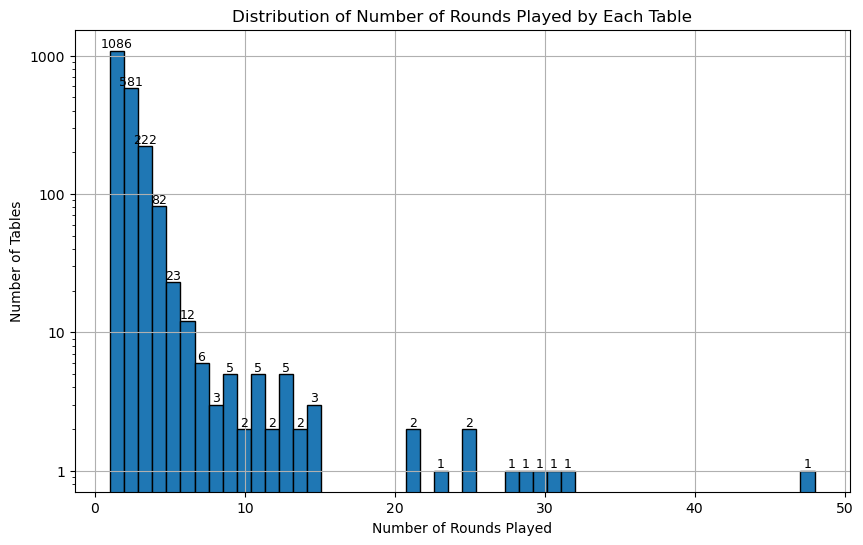

In [7]:
from matplotlib.ticker import LogLocator, ScalarFormatter
unique_tables = dataset_english['Table Number'].nunique()
print(f"Total number of unique tables: {unique_tables}")

# Step 2: Get the distribution of how many rounds each table played
table_rounds_distribution = dataset_english['Table Number'].value_counts()

# Step 3: Display the distribution as a summary
print(f"\nDistribution of rounds played by each table:\n{table_rounds_distribution}")

average_rounds_per_table = table_rounds_distribution.mean()

# Print the result
print(f"On average, each table played {average_rounds_per_table:.2f} rounds.")

# Step 4: Plot a histogram of the number of rounds played by tables with a log scale on the y-axis
plt.figure(figsize=(10, 6))

# Plot the histogram
counts, bins, patches = plt.hist(table_rounds_distribution, bins=50, edgecolor='black', color='#1f77b4')

# Set y-axis to log scale
plt.yscale('log')

# Set the y-axis tick labels to 1, 10, 100, 1000 instead of 10^0, 10^1, etc.
plt.gca().set_yticks([1, 10, 100, 1000])
plt.gca().get_yaxis().set_major_formatter(ScalarFormatter())

# Add text labels for the bin counts
for count, patch in zip(counts, patches):
    if count > 0:  # Only label non-zero bins
        plt.text(patch.get_x() + patch.get_width() / 2, count, f'{int(count)}', 
                 ha='center', va='bottom', fontsize=9)

# Set titles and labels
plt.title('Distribution of Number of Rounds Played by Each Table')
plt.xlabel('Number of Rounds Played')
plt.ylabel('Number of Tables')
plt.grid(True)

# Show the plot
plt.show()

In [51]:
# Step 1: Create a new column that indicates how many rounds a table has played so far
dataset_english['round_count'] = dataset_english.groupby('Table Number').cumcount() + 1

# Step 2: Define the independent variable (X) and dependent variable (y)
X = dataset_english[['round_count']]
y = dataset_english['Success']  # Assuming Success is binary (0 = failure, 1 = success)

# Step 3: Add a constant to the model (for the intercept)
X = sm.add_constant(X)

# Step 4: Fit the logistic regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Step 5: Print the summary of the regression results
print(result.summary())

# Optional: Get the odds ratio for each coefficient (exp(coef))
odds_ratios = pd.DataFrame({
    'Variable': X.columns,
    'Odds Ratio': result.params.apply(lambda x: np.exp(x))
})
print(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.692895
         Iterations 3
                           Logit Regression Results                           
Dep. Variable:                Success   No. Observations:                 4673
Model:                          Logit   Df Residuals:                     4671
Method:                           MLE   Df Model:                            1
Date:                 Do, 12 Sep 2024   Pseudo R-squ.:               2.360e-07
Time:                        18:23:52   Log-Likelihood:                -3237.9
converged:                       True   LL-Null:                       -3237.9
Covariance Type:            nonrobust   LLR p-value:                    0.9688
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0457      0.035      1.319      0.187      -0.022       0.114
round_count    -0.0002    

In [58]:
# Sample size
SAMPLE_SIZE = 500

# Directory to save the sample files
output_directory = 'english_sample'

# Create directory if it doesn't exist
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Function to remove duplicate clues from each round
def remove_duplicate_clues(clue_string):
    # Split the clues into a list
    clues_list = clue_string.split(',')
    
    # Strip leading/trailing whitespace and convert to lowercase for consistency
    cleaned_clues = [clue.strip().lower() for clue in clues_list]
    
    # Create a set to store unique clues
    clue_counts = {}
    
    for clue in cleaned_clues:
        if clue in clue_counts:
            clue_counts[clue] += 1
        else:
            clue_counts[clue] = 1
    
    # Keep only the unique clues (appearing once)
    unique_clues = [clue for clue in cleaned_clues if clue_counts[clue] == 1]
    
    # Return the unique clues as a comma-separated string
    return ', '.join(unique_clues)

# Function to create a random sample and save to CSV
def create_random_sample(df, sample_size):
    # Draw a random sample of 500 rounds without replacement
    sample = df.sample(n=sample_size, random_state=42)  # random_state ensures reproducibility
    
    # Remove duplicate clues from the 'Clues' column
    sample['Clues'] = sample['Clues'].apply(remove_duplicate_clues)
    
    # Select only the 'Clues' column
    sample_clues = sample[['Clues']]
    
    # Save the full sample to a CSV file
    full_output_file = f'{output_directory}/english_sample_full.csv'
    sample.to_csv(full_output_file, index=False)
    
    # Save only the clues to another CSV file
    clues_output_file = f'{output_directory}/english_sample_clues_only.csv'
    sample_clues.to_csv(clues_output_file, index=False)
    
    print(f"Sample of {sample_size} rounds saved to {full_output_file} and {clues_output_file}")

# Draw a sample of 500 rounds
create_random_sample(dataset_english, SAMPLE_SIZE)

Sample of 500 rounds saved to english_sample/english_sample_full.csv and english_sample/english_sample_clues_only.csv


In [38]:
df_chat = pd.read_csv("english_sample_with_chatgpt.csv")

dataset_english['ChatGPT_Correct'] = df_chat['ChatGPT_Correct']
dataset_english['ChatGPT_Guess'] = df_chat['ChatGPT_Guess']

In [53]:
df_chat.rename(columns={'Clues': 'Unique_Clues'}, inplace=True)

In [66]:
df_full = pd.read_csv("english_sample_full.csv")
df_full.rename(columns={'Clues': 'Unique_Clues'}, inplace=True)

In [63]:
# Function to extract unique clues from the 'Clues' column
def get_unique_clues(clue_string):
    # Split the clues by commas and strip whitespace
    clues_list = [clue.strip().lower() for clue in clue_string.split(',')]
    
    # Create a set to keep only unique clues
    unique_clues = set(clues_list)
    
    # Return the unique clues as a comma-separated string
    return ', '.join(unique_clues)

# Apply the function to the 'Clues' column and create a new column 'unique_clues'

dataset_english['Unique_Clues'] = dataset_english['Clues'].apply(get_unique_clues)

In [82]:
dataset_english.to_csv('dataset_english_before_chatgpt.csv', index=False)


In [3]:
dataset_english = pd.read_csv('dataset_english_before_chatgpt.csv')

In [81]:
df_merged = pd.merge(
    df_full[['Table Number', 'Move', 'Unique_Clues', 'Mystery Word']],
    df_chat[['Unique_Clues', 'Mystery Word', 'ChatGPT_Correct', 'ChatGPT_Guess']],
    on=['Unique_Clues', 'Mystery Word'],
    how='inner'  # or 'left', 'right', 'outer', depending on the desired behavior
)

# View the merged DataFrame
print(df_merged)

     Table Number  Move                                 Unique_Clues  \
0       454694423    37            scissors, trims, clippers, blades   
1       458068629    67              fiddle, bout, tiny, rosin, hair   
2       487207650    47           crowbar, elderly, raising, walking   
3       464501269     9           restaurant, options, dinner, lunch   
4       498525318    85                   board, yoga, surf, pirates   
..            ...   ...                                          ...   
495     508145393    53        cordless, rechargeable, power, laptop   
496     405054016  1544             hourglass, coarse, beach, grains   
497     387173467  1362              wooden, up, economics, stairway   
498     513785097    21      court, ball, sport, racket, table, pong   
499     507662998    13  frost, ice, hair, goo, toothpaste, solidify   

    Mystery Word  ChatGPT_Correct ChatGPT_Guess  
0         Shears             True        Shears  
1         Violin             True  

In [89]:
chatgpt_dataset = pd.merge(
    dataset_english[['Table Number', 'Move', 'Clues', 'Guess', 'Mode', 
                     'Language', 'End', 'Success', 'Unique_Clues', 'Mystery Word', 
                     'Is_Turn_based', 'Is_Real_time', 'Real_time_effect', 'Turn_based_effect', 
                     'average_originality', 'unique_clues_count', 'friendly_mode', 'end_infinite', 'clue_count']],
    df_merged[['Table Number', 'Move', 'ChatGPT_Correct', 'ChatGPT_Guess']],
    on=['Table Number', 'Move'],
    how='inner'  # or 'left', 'right', 'outer', depending on the desired behavior
)

# View the merged DataFrame
chatgpt_dataset.to_csv('chatgpt_dataset.csv', index=False)

In [11]:
chatgpt_dataset = pd.read_csv('chatgpt_dataset.csv')

In [ ]:
chatgpt_dataset.to_csv('chatgpt_dataset.csv', index=False)

In [92]:
# Calculate the percentage of correct guesses
human_accuracy = chatgpt_dataset['Success'].mean() * 100
chatgpt_accuracy = chatgpt_dataset['ChatGPT_Correct'].mean() * 100

# Print the results
print("Sample of n=500")
print(f"Human Accuracy: {human_accuracy:.2f}%")
print(f"ChatGPT Accuracy: {chatgpt_accuracy:.2f}%")

# Save the updated full sample with ChatGPT guesses and accuracy columns
#df_full.to_csv('english_sample_with_chatgpt.csv', index=False)

# Optional: Display summary of how often each guesser was correct


Sample of n=500
Human Accuracy: 50.40%
ChatGPT Accuracy: 71.60%


In [97]:
X = chatgpt_dataset[['unique_clues_count']] 
y = chatgpt_dataset['ChatGPT_Correct']  

X = sm.add_constant(X)
# Fit the linear regression model
linear_model = sm.OLS(y, X).fit()

# Print the summary of the regression results
print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:        ChatGPT_Success   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     50.72
Date:                 Fr, 20 Sep 2024   Prob (F-statistic):           3.74e-12
Time:                        17:38:37   Log-Likelihood:                -287.01
No. Observations:                 500   AIC:                             578.0
Df Residuals:                     498   BIC:                             586.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.1143      0

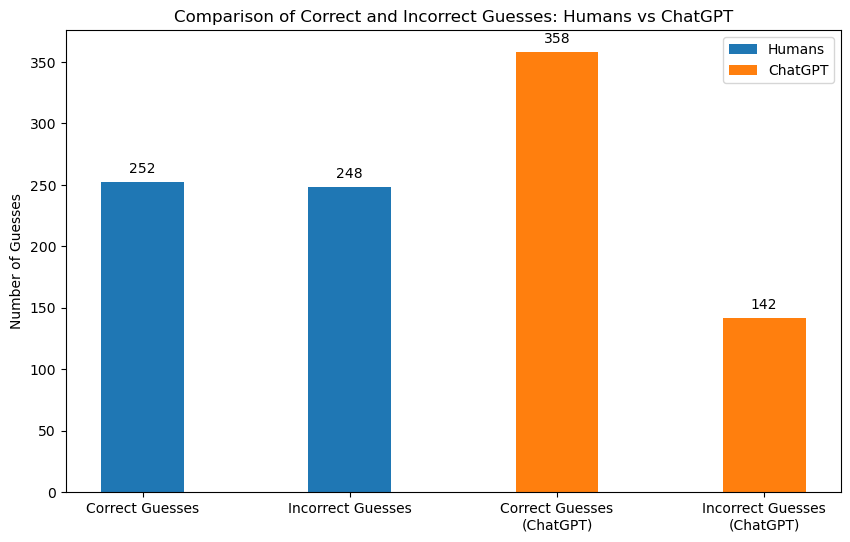

In [12]:
# Count the number of correct guesses for humans and ChatGPT
human_correct = chatgpt_dataset['Success'].sum()
chatgpt_correct = chatgpt_dataset['ChatGPT_Correct'].sum()

# Count the total number of rounds
total_rounds = len(chatgpt_dataset)

# Calculate incorrect guesses
human_incorrect = total_rounds - human_correct
chatgpt_incorrect = total_rounds - chatgpt_correct

# Create a bar chart to compare correct and incorrect guesses
labels = ['Correct Guesses', 'Incorrect Guesses']
human_values = [human_correct, human_incorrect]
chatgpt_values = [chatgpt_correct, chatgpt_incorrect]

plt.figure(figsize=(10, 6))

# Custom RGB colors for human bars (replace with your RGB values)
human_color_correct = '#1f77b4'  # Red for correct guesses
human_color_incorrect = '#1f77b4'  # Yellow for incorrect guesses

# Colors for ChatGPT bars
chatgpt_color_correct = '#ff7f0e'  # Blue for correct guesses
chatgpt_color_incorrect = '#ff7f0e'  # Green for incorrect guesses

# Plot human guesses with custom colors
bar_width = 0.4
bar1 = plt.bar(labels, human_values, width=bar_width, label='Humans', align='center', 
        color=[human_color_correct, human_color_incorrect])

# Plot ChatGPT guesses with default colors
bar_width = 0.4
bar2 = plt.bar([label + '\n(ChatGPT)' for label in labels], chatgpt_values, width=bar_width, 
        label='ChatGPT', align='center', color=[chatgpt_color_correct, chatgpt_color_incorrect])

# Add text above bars for humans
for bar in bar1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

# Add text above bars for ChatGPT
for bar in bar2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.ylabel('Number of Guesses')
plt.title('Comparison of Correct and Incorrect Guesses: Humans vs ChatGPT')
plt.legend()
plt.show()

Possible Analyses:

Effect of Specific Clues on Success:

    Analyze which types of clues (based on word frequency, length, or originality) are more likely to lead to a correct guess.
    Run regressions with additional predictors such as word length or commonality of clues in the dataset.

Analysis of Clue Patterns:

    Examine whether the types of clues used by humans in rounds where they succeed are different from those where ChatGPT succeeds.
    Use clustering techniques to analyze clue patterns for both ChatGPT and human guesses.

Effect of Clue Originality:

    Investigate whether more "original" clues, measured by the distance between clues and mystery words, affect the success rate of both human and ChatGPT guessers.

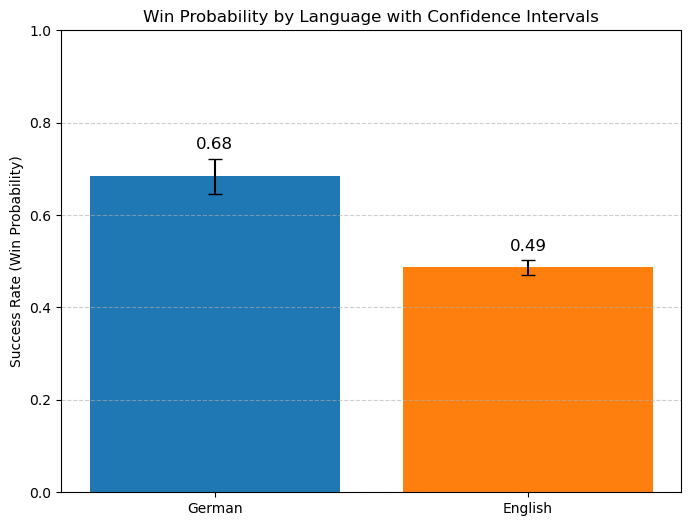

In [13]:
both_languages = pd.read_csv('combined_dataset_originality.csv')
german_data = both_languages[both_languages['Language'] == 'Deutsch']
english_data = both_languages[both_languages['Language'] == 'English']

# Calculate success rates (win probabilities)
german_success_rate = german_data['Success'].mean()
english_success_rate = english_data['Success'].mean()

# Function to calculate the 95% confidence interval for proportions
def confidence_interval(success_rate, n, confidence=0.95):
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    margin_of_error = z * np.sqrt((success_rate * (1 - success_rate)) / n)
    return margin_of_error

# Calculate the number of observations for each language
german_n = german_data.shape[0]
english_n = english_data.shape[0]

# Calculate confidence intervals for each language
german_ci = confidence_interval(german_success_rate, german_n)
english_ci = confidence_interval(english_success_rate, english_n)

# Plot the results in a bar chart with error bars
languages = ['German', 'English']
success_rates = [german_success_rate, english_success_rate]
confidence_intervals = [german_ci, english_ci]

# Create the bar plot
plt.figure(figsize=(8, 6))
plt.bar(languages, success_rates, yerr=confidence_intervals, capsize=5, color=['#1f77b4', '#ff7f0e'])
plt.ylabel('Success Rate (Win Probability)')
plt.title('Win Probability by Language with Confidence Intervals')
plt.ylim(0, 1)  # Set y-axis limit between 0 and 1

# Add labels above the bars with a slight vertical offset above the error bars
for i, (rate, ci) in enumerate(zip(success_rates, confidence_intervals)):
    plt.text(i, rate + ci + 0.02, f'{rate:.2f}', ha='center', fontsize=12)  # Adding ci and a small offset (0.02) to ensure it's above the error bars


plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

In [15]:
# Define the dependent variable (Success)
y = dataset_english['Success']


In [16]:
# Model 1: Only Unique Clues
X1 = dataset_english[['unique_clues_count']]
X1 = sm.add_constant(X1)  # Add constant for intercept
model1 = sm.OLS(y, X1).fit()

# Print summary for Model 1
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                Success   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     54.90
Date:                 Sa, 28 Sep 2024   Prob (F-statistic):           1.53e-13
Time:                        22:57:23   Log-Likelihood:                -2939.7
No. Observations:                4090   AIC:                             5883.
Df Residuals:                    4088   BIC:                             5896.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.3082      0

In [17]:
# Model 3: Unique Clues + Game Speed
X2 = dataset_english[['unique_clues_count', 'average_originality']]
X2 = sm.add_constant(X2)
model2 = sm.OLS(y, X2).fit()

# Print summary for Model 2
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                Success   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     31.62
Date:                 Sa, 28 Sep 2024   Prob (F-statistic):           2.37e-14
Time:                        22:57:56   Log-Likelihood:                -2935.6
No. Observations:                4090   AIC:                             5877.
Df Residuals:                    4087   BIC:                             5896.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.4349    

In [40]:
# Model 2: Unique Clues + Game Speed + Mode
X3 = dataset_english[['average_originality']]
X3 = sm.add_constant(X3)
model3 = sm.OLS(y, X3).fit()

# Print summary for Model 3
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:     unique_clues_count   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     126.1
Date:                 Mi, 02 Okt 2024   Prob (F-statistic):           7.74e-29
Time:                        12:23:06   Log-Likelihood:                -7108.1
No. Observations:                4090   AIC:                         1.422e+04
Df Residuals:                    4088   BIC:                         1.423e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.8462    

In [19]:
# Model 4: Unique Clues + Game Speed + Mode + End
X4 = dataset_english[['unique_clues_count', 'average_originality', 'Turn_based_effect', 'Real_time_effect', 'friendly_mode', 'end_infinite']]
X4 = sm.add_constant(X4)
model4 = sm.OLS(y, X4).fit()

# Print summary for Model 4
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                Success   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     5.578
Date:                 Di, 15 Okt 2024   Prob (F-statistic):           8.99e-06
Time:                        15:52:33   Log-Likelihood:                -2950.3
No. Observations:                4090   AIC:                             5915.
Df Residuals:                    4083   BIC:                             5959.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.4215    

In [13]:
# Save the regression results as a LaTeX file for use in tables
with open('regression_results.tex', 'w') as f:
    f.write(model1.summary().as_latex())
    f.write(model2.summary().as_latex())
    f.write(model3.summary().as_latex())
    f.write(model4.summary().as_latex())

Success rate in last round for tables that played more than 3 rounds: 0.50
Success rate in last round for tables that played 3 or fewer rounds: 0.47


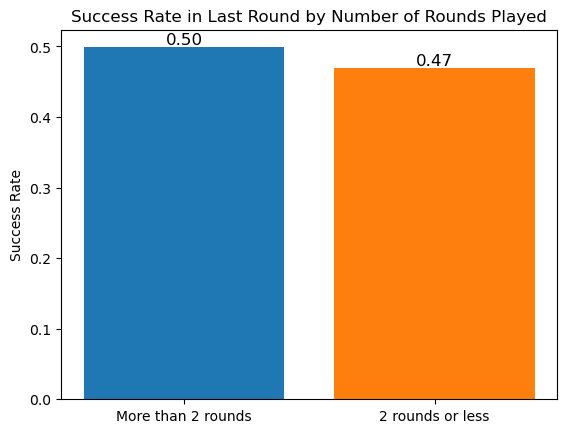

In [9]:
# Step 1: Create a copy of the main dataset for this analysis
dataset_comparison = dataset_english.copy()

# Step 2: Count the number of rounds each table plays
table_rounds_count = dataset_comparison.groupby('Table Number')['Move'].count().reset_index()
table_rounds_count.columns = ['Table Number', 'total_rounds']

# Step 3: Merge the total_rounds into the copied dataset
dataset_comparison = pd.merge(dataset_comparison, table_rounds_count, on='Table Number')

# Step 4: Identify the last round for each table by finding the highest move number
last_rounds = dataset_comparison.loc[dataset_comparison.groupby('Table Number')['Move'].idxmax()]

# Step 5: Split the last_rounds dataset into tables that played more than 3 rounds and those that played 3 or fewer rounds
tables_more_than_3 = last_rounds[last_rounds['total_rounds'] > 2]
tables_3_or_fewer = last_rounds[last_rounds['total_rounds'] <= 2]

# Step 6: Calculate the success rate in the last round for both groups
success_rate_more_than_3 = tables_more_than_3['Success'].mean()
success_rate_3_or_fewer = tables_3_or_fewer['Success'].mean()

# Step 7: Print the results
print(f"Success rate in last round for tables that played more than 3 rounds: {success_rate_more_than_3:.2f}")
print(f"Success rate in last round for tables that played 3 or fewer rounds: {success_rate_3_or_fewer:.2f}")

# Optional: You can plot these results for comparison
import matplotlib.pyplot as plt

# Create a bar plot to compare success rates
labels = ['More than 2 rounds', '2 rounds or less']
success_rates = [success_rate_more_than_3, success_rate_3_or_fewer]

# Plot the bars
bars = plt.bar(labels, success_rates, color=['#1f77b4', '#ff7f0e'])

# Add labels and title
plt.ylabel('Success Rate')
plt.title('Success Rate in Last Round by Number of Rounds Played')

# Add the success rate values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom', fontsize=12)

# Display the plot
plt.show()

In [52]:
deutsch_data = pd.read_csv('german_originality.csv')
deutsch_data['clue_count'] = deutsch_data['Clues'].apply(count_clues)
deutsch_data['unique_clues_count'] = deutsch_data['Clues'].apply(count_unique_clues)



In [53]:
deutsch_data = deutsch_data.dropna(subset=['average_originality'])

In [54]:
# Check for NaN values in the dataset
print(deutsch_data.isnull().sum())

Table Number           0
Move                   0
Clues                  0
Mystery Word           0
Guess                  0
Mode                   0
Language               0
End                    0
Success                0
Is_Turn_based          0
Is_Real_time           0
Turn_based_effect      0
Real_time_effect       0
language_german        0
language_french        0
friendly_mode          0
end_infinite           0
average_originality    0
clue_count             0
unique_clues_count     0
dtype: int64


In [55]:
y_german = deutsch_data['Success']

# Define the independent variables for the regression
X_german = deutsch_data[['unique_clues_count', 'average_originality', 'Real_time_effect', 
                           'Turn_based_effect', 'friendly_mode', 'end_infinite']]

# Add a constant for the intercept
X_german = sm.add_constant(X_german)

# Fit the OLS regression model
model_german = sm.OLS(y_german, X_german).fit()

# Display the summary
print(model_german.summary())

                            OLS Regression Results                            
Dep. Variable:                Success   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     9.435
Date:                 Do, 03 Okt 2024   Prob (F-statistic):           6.78e-10
Time:                        00:51:24   Log-Likelihood:                -353.20
No. Observations:                 583   AIC:                             720.4
Df Residuals:                     576   BIC:                             751.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.6481    

In [56]:
y_german = deutsch_data['unique_clues_count']

# Define the independent variables for the regression
X_german = deutsch_data[['average_originality', 'Real_time_effect', 
                           'Turn_based_effect', 'friendly_mode', 'end_infinite']]

# Add a constant for the intercept
X_german = sm.add_constant(X_german)

# Fit the OLS regression model
model_german = sm.OLS(y_german, X_german).fit()

# Display the summary
print(model_german.summary())

                            OLS Regression Results                            
Dep. Variable:     unique_clues_count   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     4.019
Date:                 Do, 03 Okt 2024   Prob (F-statistic):            0.00136
Time:                        00:52:50   Log-Likelihood:                -987.69
No. Observations:                 583   AIC:                             1987.
Df Residuals:                     577   BIC:                             2014.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.6665    

In [4]:
from nltk.stem import WordNetLemmatizer

# Initialize the WordNet Lemmatizer
lemmatizer = WordNetLemmatizer()

def check_clue_contains_mystery_root(clue_string, mystery_word):
    # Lemmatize the mystery word to its root
    mystery_root = lemmatizer.lemmatize(mystery_word.lower())
    
    # Split the clues by comma or other delimiters and lemmatize each clue
    clues_list = clue_string.split(',')
    clues_root = [lemmatizer.lemmatize(clue.strip().lower()) for clue in clues_list]
    
    # Check if any clue contains the root of the mystery word
    for clue in clues_root:
        if mystery_root in clue:
            return True  # The clue contains the root of the mystery word
    return False

# Apply the function to your dataset
dataset_english['contains_mystery_root'] = dataset_english.apply(
    lambda row: check_clue_contains_mystery_root(row['Clues'], row['Mystery Word']), axis=1
)

# Now you can check how many rows contain clues with the root of the mystery word
root_violations = dataset_english['contains_mystery_root'].sum()
print(f'Total clues containing the root of the mystery word: {root_violations}')

Total clues containing the root of the mystery word: 11


In [5]:
from nltk.stem import PorterStemmer

# Initialize the Porter Stemmer
stemmer = PorterStemmer()

def check_clue_contains_mystery_stem(clue_string, mystery_word):
    # Stem the mystery word
    mystery_stem = stemmer.stem(mystery_word.lower())

    # Split the clues by comma and stem each clue
    clues_list = clue_string.split(',')
    clues_stem = [stemmer.stem(clue.strip().lower()) for clue in clues_list]

    # Check if any clue contains the stem of the mystery word
    for clue in clues_stem:
        if mystery_stem in clue:
            return True  # The clue contains the stem of the mystery word
    return False

# Apply the function to your dataset
dataset_english['contains_mystery_stem'] = dataset_english.apply(
    lambda row: check_clue_contains_mystery_stem(row['Clues'], row['Mystery Word']), axis=1
)

# Check how many rows contain clues with the stem of the mystery word
stem_violations = dataset_english['contains_mystery_stem'].sum()
print(f'Total clues containing the stem of the mystery word: {stem_violations}')

Total clues containing the stem of the mystery word: 13


In [6]:
def check_clue_contains_mystery_stem_or_substring(clue_string, mystery_word):
    # Stem the mystery word
    mystery_stem = stemmer.stem(mystery_word.lower())
    mystery_word_lower = mystery_word.lower()

    # Split the clues and check both stems and substrings
    clues_list = clue_string.split(',')
    for clue in clues_list:
        clue_cleaned = clue.strip().lower()
        clue_stem = stemmer.stem(clue_cleaned)
        if mystery_stem in clue_stem or mystery_word_lower in clue_cleaned:
            return True  # The clue contains the stem or part of the mystery word
    return False

# Apply the function to your dataset
dataset_english['contains_mystery_stem_or_substring'] = dataset_english.apply(
    lambda row: check_clue_contains_mystery_stem_or_substring(row['Clues'], row['Mystery Word']), axis=1
)

# Check how many rows contain clues with the stem or part of the mystery word
stem_or_substring_violations = dataset_english['contains_mystery_stem_or_substring'].sum()
print(f'Total clues containing the stem or substring of the mystery word: {stem_or_substring_violations}')

Total clues containing the stem or substring of the mystery word: 14


### Regression Results Summary

The regression model includes two predictors: **unique_clues_count** and **unique_clues_squared**. The results suggest a **non-linear relationship** between unique clues and success, where the number of unique clues initially increases success, but after a certain point, further increases in unique clues reduce the likelihood of success.

#### Key Results:
- **unique_clues_count**: The coefficient is **0.1738**, indicating that for each additional unique clue, the likelihood of success increases by 0.1738. This effect is statistically significant with a p-value of **0.001**.
  
- **unique_clues_squared**: The coefficient is **-0.0154**, showing that after a certain number of unique clues, the effect becomes negative, reducing the chances of success. This suggests a **humpback-shaped** relationship. The effect is significant with a p-value of **0.009**.

These findings indicate that while unique clues can improve success initially, there is an **optimal point** beyond which adding more unique clues becomes counterproductive.

In [16]:
dataset_english['unique_clues_squared'] = dataset_english['unique_clues_count'] ** 2

X = dataset_english[['unique_clues_count', 'unique_clues_squared']]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Success   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     14.34
Date:                 Di, 15 Okt 2024   Prob (F-statistic):           6.21e-07
Time:                        14:47:40   Log-Likelihood:                -2952.7
No. Observations:                4090   AIC:                             5911.
Df Residuals:                    4087   BIC:                             5930.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0257 

In [17]:
# Create interaction term
dataset_english['unique_clues_originality_interaction'] = dataset_english['unique_clues_count'] * dataset_english['average_originality']

# Regression with interaction term
X_interaction = dataset_english[['unique_clues_count', 'average_originality', 'unique_clues_originality_interaction']]
X_interaction = sm.add_constant(X_interaction)  # Add constant for intercept

# Fit the model
interaction_model = sm.OLS(y, X_interaction).fit()

# Print summary
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Success   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     9.117
Date:                 Di, 15 Okt 2024   Prob (F-statistic):           5.19e-06
Time:                        15:24:22   Log-Likelihood:                -2953.4
No. Observations:                4090   AIC:                             5915.
Df Residuals:                    4086   BIC:                             5940.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
